# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


# Lab Work
### Target:
Api Availability (api_availablity)
### Research Question: 
"What characteristics make a generative AI tool more likely to offer an API?"
### Features:
1. open_source - Does being open source correlate with API availability?
2. category_canonical - Which categories are more likely to have APIs?
3. release_year - Do newer tools have more APIs?
4. modality_canonical - Which modalities influence API availability?
5. years_since_release - Does maturity correlate with API offering?

### Big Picture
  The data suggests that modality type is the strongest predictor of whether an AI tool will offer an API. This indicates that modality plays a crucial role in API strategy decisions. Image and Video Generations modality types have the lowest API adoption rate. 

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno
import plotly.express as px
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Load your chosen dataset
df = pd.read_csv('ai_platforms.csv', low_memory=False)

# Understand the structure
df.head()




,tool_name,company,category_canonical,modality_canonical,open_source,api_available,api_status,website,source_domain,release_year,...,mod_image,mod_video,mod_audio,mod_code,mod_design,mod_infra,mod_productivity,mod_safety,mod_multimodal,modality_count
0,ChatGPT,OpenAI,LLMs & Chat Assistants,multimodal,0,1,api,https://chatgpt.com,chatgpt.com,2022,...,0,0,0,0,0,0,0,0,1,0
1,Claude,Anthropic,LLMs & Chat Assistants,multimodal,0,1,api,https://claude.ai,claude.ai,2023,...,0,0,0,0,0,0,0,0,1,0
2,Gemini,Google,LLMs & Chat Assistants,multimodal,0,1,api,https://gemini.google.com,gemini.google.com,2023,...,0,0,0,0,0,0,0,0,1,0
3,Midjourney,Midjourney,Image Gen & Editing,image,0,0,unavailable,https://www.midjourney.com,midjourney.com,2022,...,1,0,0,0,0,0,0,0,0,1
4,Stable Diffusion,Stability AI,Image Gen & Editing,image,1,1,api,https://stability.ai/stable-image,stability.ai,2022,...,1,0,0,0,0,0,0,0,0,1


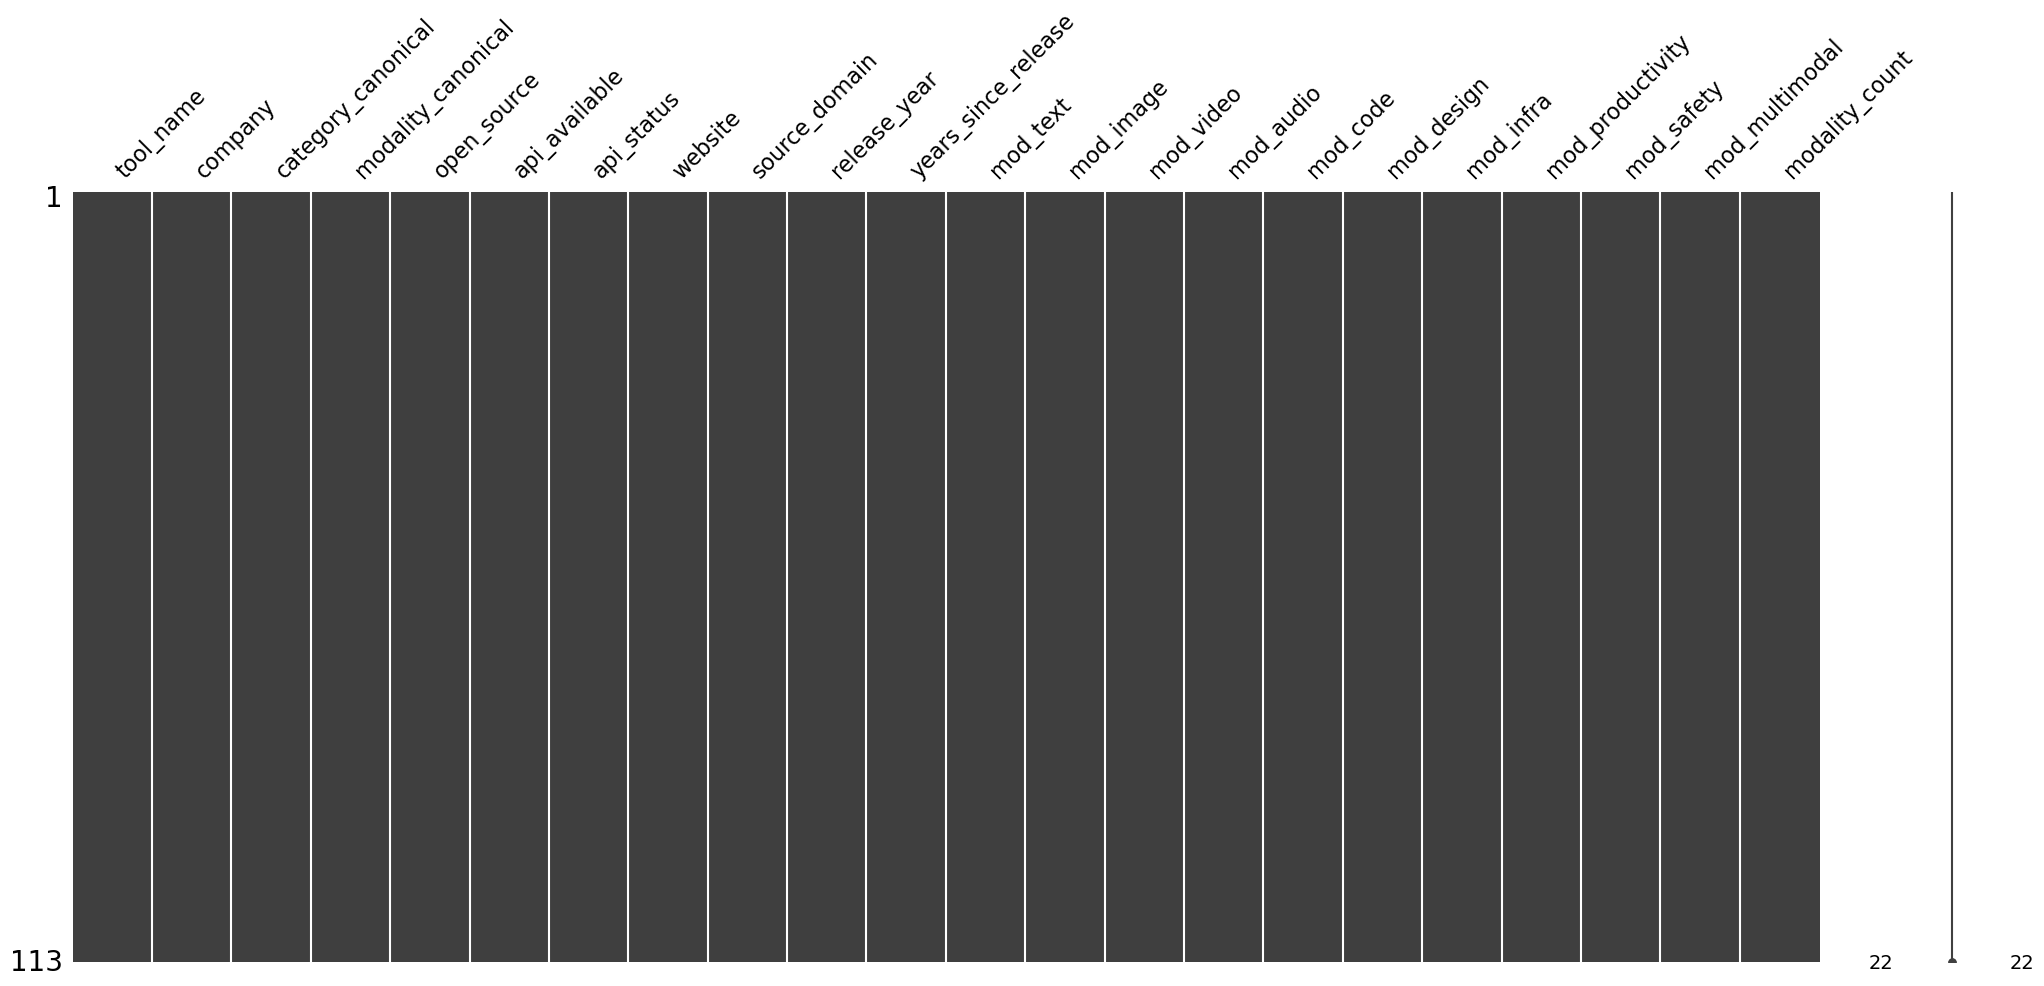

In [126]:
msno.matrix(df)
plt.show()

In [120]:
TARGET = 'api_available'
FEATURES = [
    'open_source',           # Does open source correlate with API availability?
    'category_canonical',    # Which categories prioritize APIs?
    'release_year',         # Do newer tools offer more APIs?
    'modality_canonical',   # Does modality type affect API strategy?
    'years_since_release'   # Does maturity correlate with API offering?
]

print("=== API AVAILABILITY ANALYSIS ===")
print(f"Target Variable: {TARGET}")
print(f"Research Question: What factors influence whether an AI tool offers an API?")
print()

# Create clean dataset for analysis
analysis_df = df[FEATURES + [TARGET]].copy()

# Basic target variable analysis
print("TARGET VARIABLE DISTRIBUTION:")
target_dist = analysis_df[TARGET].value_counts().sort_index()
print(target_dist)
print(f"API Availability Rate: {analysis_df[TARGET].mean():.1%}")
print()

# Check data quality
print("DATA QUALITY CHECK:")
print(f"Total rows: {len(analysis_df)}")
print(f"Missing values per column:")
missing_data = analysis_df.isnull().sum()
print(missing_data[missing_data > 0])

# Clean the dataset
analysis_df = analysis_df.dropna(subset=[TARGET])
print(f"Rows after removing missing targets: {len(analysis_df)}")

=== API AVAILABILITY ANALYSIS ===
Target Variable: api_available
Research Question: What factors influence whether an AI tool offers an API?

TARGET VARIABLE DISTRIBUTION:
api_available
0      6
1    107
Name: count, dtype: int64
API Availability Rate: 94.7%

DATA QUALITY CHECK:
Total rows: 113
Missing values per column:
Series([], dtype: int64)
Rows after removing missing targets: 113


In [ ]:
print("\n=== FEATURE EXPLORATION ===")

# 1. Open Source Analysis
if 'open_source' in analysis_df.columns:
    print("\n1. OPEN SOURCE STATUS:")
    os_crosstab = pd.crosstab(analysis_df['open_source'], analysis_df[TARGET], margins=True)
    print(os_crosstab)
    
    # Calculate API rates by open source status
    os_rates = analysis_df.groupby('open_source')[TARGET].agg(['count', 'sum', 'mean'])
    print("\nAPI Rates by Open Source Status:")
    print(os_rates)

# 2. Category Analysis  
if 'category_canonical' in analysis_df.columns:
    print("\n2. CATEGORY ANALYSIS:")
    cat_analysis = analysis_df.groupby('category_canonical')[TARGET].agg(['count', 'mean']).round(3)
    cat_analysis = cat_analysis.sort_values('mean', ascending=False)
    print("API Availability by Category (sorted by rate):")
    print(cat_analysis)

# 3. Release Year Analysis
if 'release_year' in analysis_df.columns:
    print("\n3. TEMPORAL TRENDS:")
    year_analysis = analysis_df.groupby('release_year')[TARGET].agg(['count', 'mean']).round(3)
    print("API Availability by Release Year:")
    print(year_analysis[year_analysis['count'] >= 2])  # Only years with multiple tools

# 4. 


=== FEATURE EXPLORATION ===

1. OPEN SOURCE STATUS:
api_available  0    1  All
open_source               
0              5   66   71
1              1   41   42
All            6  107  113

API Rates by Open Source Status:
             count  sum      mean
open_source                      
0               71   66  0.929577
1               42   41  0.976190

2. CATEGORY ANALYSIS:
API Availability by Category (sorted by rate):
                         count   mean
category_canonical                   
Audio/Music/TTS              6  1.000
Code Assistants              1  1.000
Design & UI                  4  1.000
Evaluation & Benchmarks      2  1.000
Infra & Inference            3  1.000
Speech-to-Text (ASR)         1  1.000
LLMs & Chat Assistants      32  1.000
Productivity & Copilots      1  1.000
Safety & Guardrails          5  1.000
Search & RAG                 6  1.000
Other                       27  0.963
Video Gen & Editing         13  0.846
Image Gen & Editing         12  0.750

3

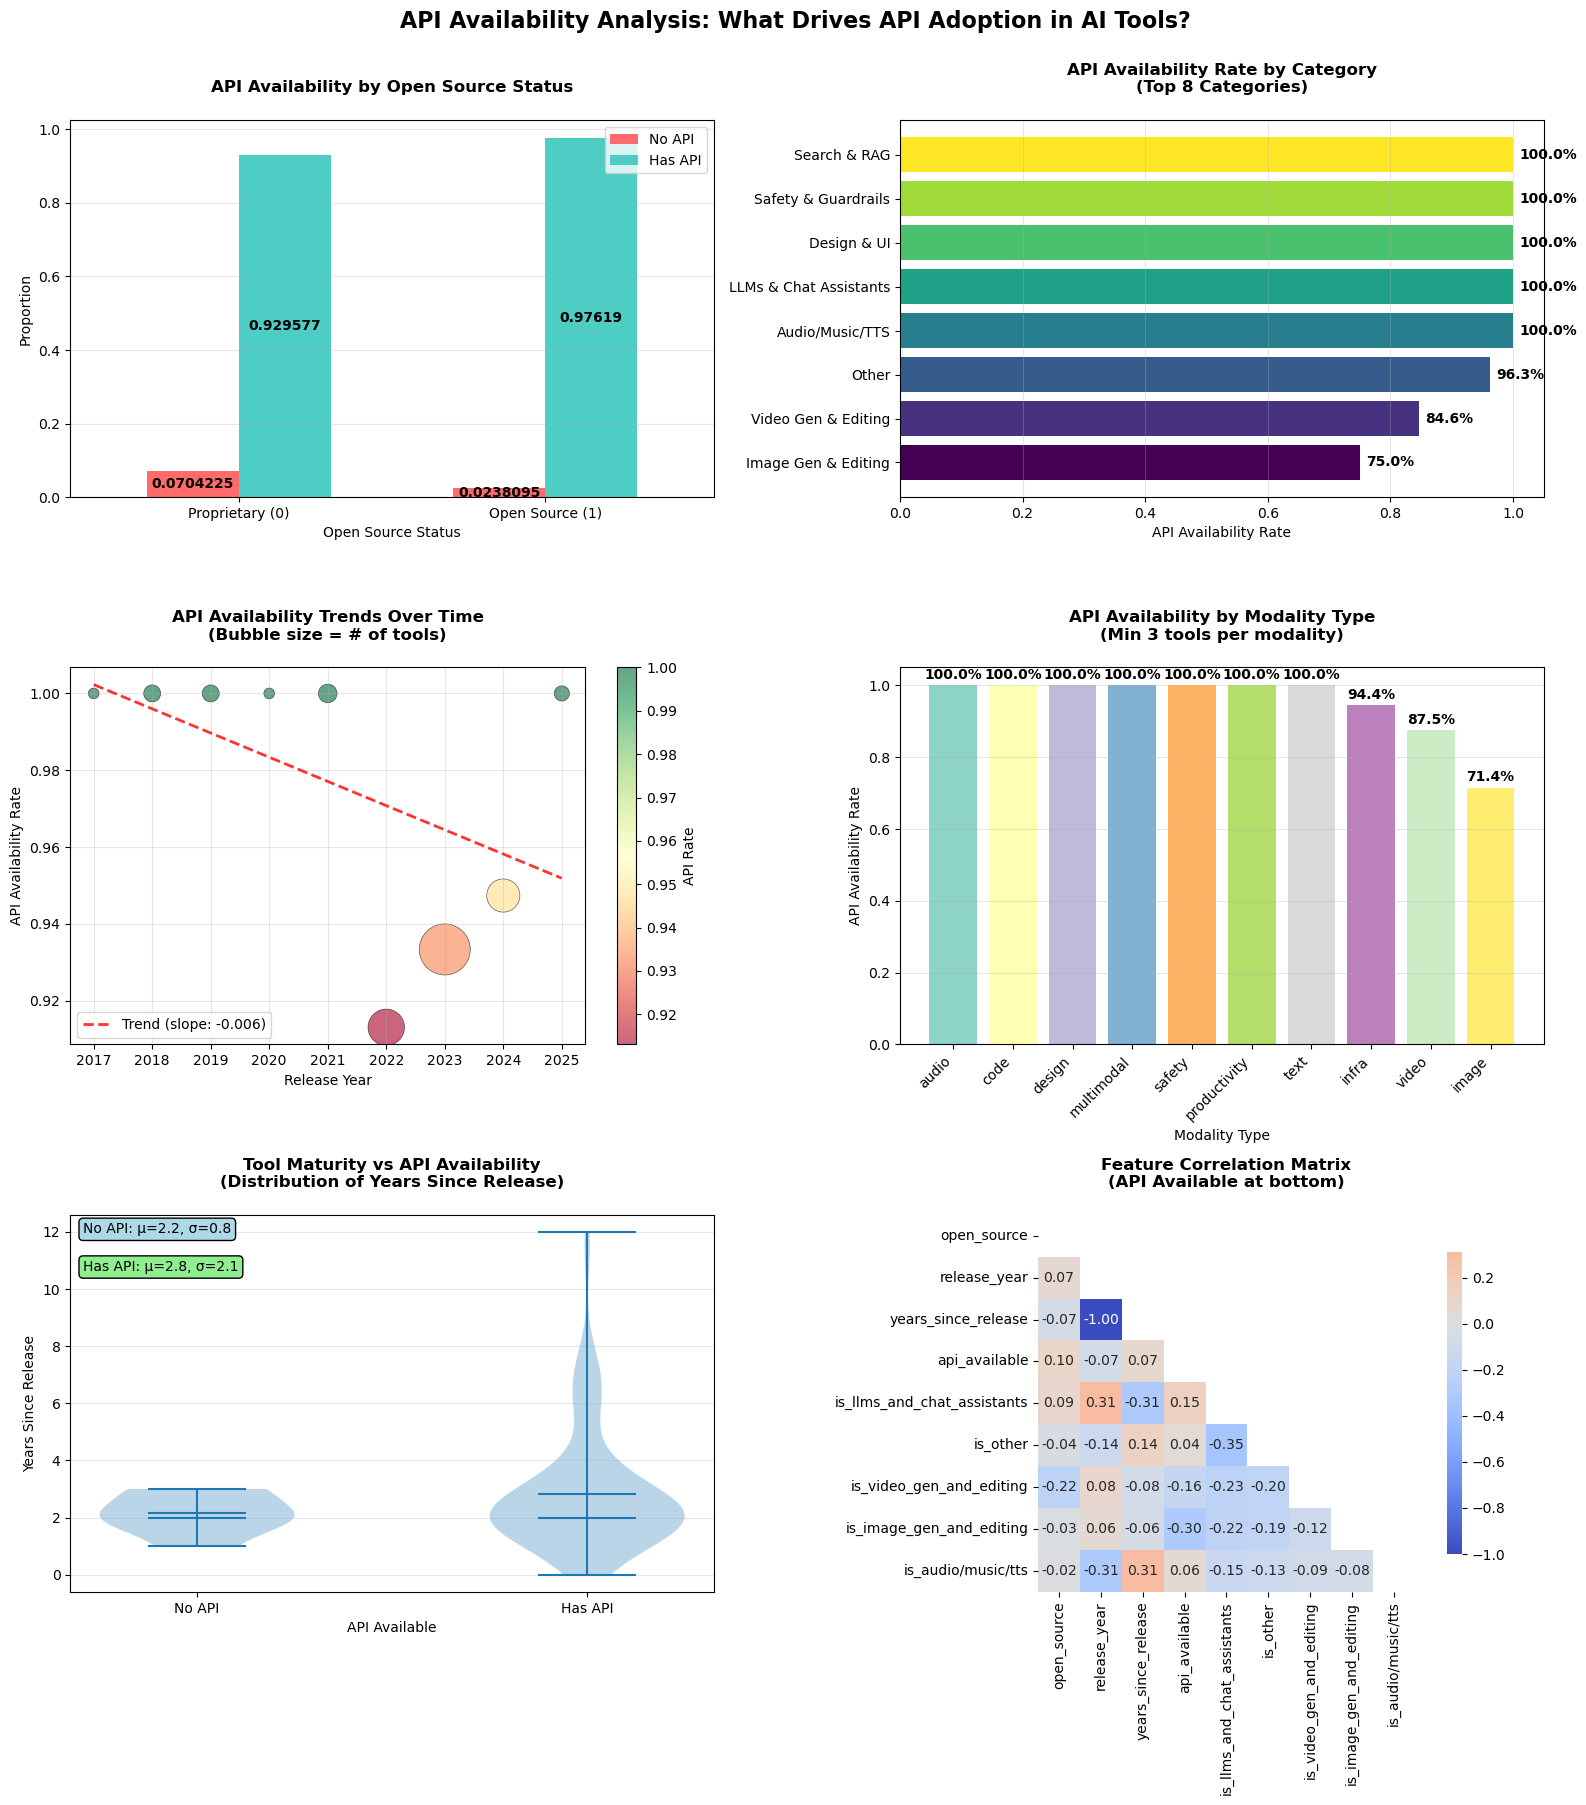

In [122]:
# Create a comprehensive visualization dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('API Availability Analysis: What Drives API Adoption in AI Tools?', 
             fontsize=16, fontweight='bold', y=1)

# Set color palette
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

# 1. Open Source vs API Availability
ax1 = axes[0, 0]
if 'open_source' in analysis_df.columns:
    # Create percentage stacked bar chart
    os_crosstab_pct = pd.crosstab(analysis_df['open_source'], analysis_df[TARGET], normalize='index')
    os_crosstab_pct.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4'], width=0.6)
    ax1.set_title('API Availability by Open Source Status', fontweight='bold', pad=20)
    ax1.set_xlabel('Open Source Status')
    ax1.set_ylabel('Proportion')
    ax1.set_xticklabels(['Proprietary (0)', 'Open Source (1)'], rotation=0)
    ax1.legend(['No API', 'Has API'], loc='upper right')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add percentage labels
    for container in ax1.containers:
        ax1.bar_label(container,label_type='center', fontweight='bold')

# 2. Category Analysis - Top Categories Only
ax2 = axes[0, 1]
if 'category_canonical' in analysis_df.columns:
    # Get top 8 categories by count
    top_categories = analysis_df['category_canonical'].value_counts().head(8).index
    cat_subset = analysis_df[analysis_df['category_canonical'].isin(top_categories)]
    
    cat_rates = cat_subset.groupby('category_canonical')[TARGET].mean().sort_values(ascending=True)
    bars = ax2.barh(range(len(cat_rates)), cat_rates.values, 
                    color=plt.cm.viridis(np.linspace(0, 1, len(cat_rates))))
    ax2.set_title('API Availability Rate by Category\n(Top 8 Categories)', fontweight='bold', pad=20)
    ax2.set_xlabel('API Availability Rate')
    ax2.set_yticks(range(len(cat_rates)))
    ax2.set_yticklabels([cat[:25] + '...' if len(cat) > 25 else cat for cat in cat_rates.index])
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(cat_rates.values):
        ax2.text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold')

# 3. Release Year Trend Analysis
ax3 = axes[1, 0]
if 'release_year' in analysis_df.columns:
    year_data = analysis_df.groupby('release_year').agg({
        TARGET: ['count', 'sum', 'mean']
    }).reset_index()
    year_data.columns = ['release_year', 'total_tools', 'tools_with_api', 'api_rate']
    
    # Filter to years with at least 2 tools for statistical significance
    year_data = year_data[year_data['total_tools'] >= 2]
    
    # Create scatter plot with trend line
    scatter = ax3.scatter(year_data['release_year'], year_data['api_rate'], 
                         s=year_data['total_tools']*30, alpha=0.6, 
                         c=year_data['api_rate'], cmap='RdYlGn', 
                         edgecolors='black', linewidth=0.5)
    
    # Add trend line
    z = np.polyfit(year_data['release_year'], year_data['api_rate'], 1)
    p = np.poly1d(z)
    ax3.plot(year_data['release_year'], p(year_data['release_year']), 
             "r--", alpha=0.8, linewidth=2, label=f'Trend (slope: {z[0]:.3f})')
    
    ax3.set_title('API Availability Trends Over Time\n(Bubble size = # of tools)', fontweight='bold', pad=20)
    ax3.set_xlabel('Release Year')
    ax3.set_ylabel('API Availability Rate')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Add colorbar
    plt.colorbar(scatter, ax=ax3, label='API Rate')

# 4. Modality Analysis
ax4 = axes[1, 1]
if 'modality_canonical' in analysis_df.columns:
    mod_analysis = analysis_df.groupby('modality_canonical')[TARGET].agg(['count', 'mean'])
    mod_analysis = mod_analysis[mod_analysis['count'] >= 3].sort_values('mean', ascending=False)
    
    bars = ax4.bar(range(len(mod_analysis)), mod_analysis['mean'], 
                   color=plt.cm.Set3(np.linspace(0, 1, len(mod_analysis))))
    ax4.set_title('API Availability by Modality Type\n(Min 3 tools per modality)', fontweight='bold', pad=20)
    ax4.set_xlabel('Modality Type')
    ax4.set_ylabel('API Availability Rate')
    ax4.set_xticks(range(len(mod_analysis)))
    ax4.set_xticklabels(mod_analysis.index, rotation=45, ha='right')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

# 5. Years Since Release Distribution
ax5 = axes[2, 0]
if 'years_since_release' in analysis_df.columns:
    # Create violin plot showing distribution
    api_no = analysis_df[analysis_df[TARGET] == 0]['years_since_release']
    api_yes = analysis_df[analysis_df[TARGET] == 1]['years_since_release']
    
    parts = ax5.violinplot([api_no, api_yes], positions=[0, 1], showmeans=True, showmedians=True)
    ax5.set_title('Tool Maturity vs API Availability\n(Distribution of Years Since Release)', 
                  fontweight='bold', pad=20)
    ax5.set_xlabel('API Available')
    ax5.set_ylabel('Years Since Release')
    ax5.set_xticks([0, 1])
    ax5.set_xticklabels(['No API', 'Has API'])
    ax5.grid(axis='y', alpha=0.3)
    
    # Add statistics
    ax5.text(0.02, 0.98, f'No API: μ={api_no.mean():.1f}, σ={api_no.std():.1f}', 
             transform=ax5.transAxes, va='top', bbox=dict(boxstyle='round', facecolor='lightblue'))
    ax5.text(0.02, 0.88, f'Has API: μ={api_yes.mean():.1f}, σ={api_yes.std():.1f}', 
             transform=ax5.transAxes, va='top', bbox=dict(boxstyle='round', facecolor='lightgreen'))

# 6. Feature Correlation Heatmap
ax6 = axes[2, 1]
# Create dummy variables for categorical features
analysis_encoded = analysis_df.copy()

# Convert categorical to numerical for correlation
if 'category_canonical' in analysis_encoded.columns:
    # Use the most common categories as binary features
    top_cats = analysis_encoded['category_canonical'].value_counts().head(5).index
    for cat in top_cats:
        analysis_encoded[f'is_{cat.replace(" ", "_").replace("&", "and").lower()}'] = (
            analysis_encoded['category_canonical'] == cat).astype(int)

# Select numerical columns for correlation
numerical_cols = analysis_encoded.select_dtypes(include=[np.number]).columns
corr_matrix = analysis_encoded[numerical_cols].corr()

# Plot heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, ax=ax6,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
ax6.set_title('Feature Correlation Matrix\n(API Available at bottom)', fontweight='bold', pad=20)

plt.tight_layout()
plt.show()